### This notebook extract newly generated molecules after the DORAnet run: 

In [1]:
import os
import glob
import pandas as pd
from pathlib import Path
from collections import defaultdict
from rdkit import RDLogger
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Draw
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import io
import json
import math
import time

RDLogger.DisableLog('rdApp.*')

In [2]:
from DORA_XGB import DORA_XGB
by_desc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_descending_MW')
by_asc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_ascending_MW')
add_concat_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_concat')
add_subtract_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_subtract')

/users/sghosh6/.conda/envs/doranet_env/lib/python3.10/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
fileNamePrefix = "basidalinPrecursor_gen2"

### Discover All Starter Directories

In [4]:
doranetOutputDir = "doranet_output"

helpersToExclude = {
    'O', 'O=O', '[H][H]', 'O=C=O', 'C=O', '[C-]#[O+]', 'Br', '[Br][Br]',
    'CO', 'C=C', 'O=S(O)O', 'N', 'O=S(=O)(O)O', 'O=NO', 'N#N',
    'O=[N+]([O-])O', 'NO', 'C#N', 'S', 'O=S=O', 'N#CO', '[H+]', 'OO',
    'Cl', 'I', 'O=C(O)O', 'O=P(O)(O)O', 'O=P(O)(O)OP(=O)(O)O', 'C',
    'CC', 'CC=O', 'CC(=O)O', 'CCC(=O)O'
}

print(f"Output directory: {doranetOutputDir}")
print(f"Number of helpers to exclude: {len(helpersToExclude)}")

Output directory: doranet_output
Number of helpers to exclude: 33


In [5]:
# Automatically find all starter directories (exclude files)
allStarterDirPaths = sorted([
    p for p in glob.glob(os.path.join(doranetOutputDir, "starter_*"))
    if os.path.isdir(p)
])

print(f"Found {len(allStarterDirPaths)} starter directories")

# Find the molecules CSV file inside each directory
discoveredCsvFiles = []
directoriesWithMissingCsv = []

for starterDirPath in allStarterDirPaths:
    dirName = os.path.basename(starterDirPath)

    # Expected CSV file name matches directory name
    expectedCsvPath = os.path.join(starterDirPath, f"{dirName}_molecules.csv")

    if os.path.exists(expectedCsvPath):
        discoveredCsvFiles.append({
            'dirName': dirName,
            'dirPath': starterDirPath,
            'csvPath': expectedCsvPath,
            'starterNum': int(dirName.replace('starter_', ''))
        })
    else:
        # Try to find any molecules CSV in the directory as fallback
        fallbackCsvPaths = glob.glob(os.path.join(starterDirPath, "*_molecules.csv"))
        if fallbackCsvPaths:
            discoveredCsvFiles.append({
                'dirName': dirName,
                'dirPath': starterDirPath,
                'csvPath': fallbackCsvPaths[0],
                'starterNum': int(dirName.replace('starter_', ''))
            })
        else:
            directoriesWithMissingCsv.append(dirName)

# Sort by starter number
discoveredCsvFiles.sort(key=lambda x: x['starterNum'])

print(f"Found {len(discoveredCsvFiles)} CSV files containing DORAnet generated molecules")
if directoriesWithMissingCsv:
    print(f"Missing CSV in {len(directoriesWithMissingCsv)} directories: "
          f"{directoriesWithMissingCsv[:10]}...")

Found 2054 starter directories
Found 2054 CSV files containing DORAnet generated molecules


### Extract the `DORAnet` starter molecule

In [6]:
user_starters = set()
starterReadErrors = []

for fileInfo in discoveredCsvFiles:
    try:
        # Read only the SMILES and Is_Starter columns to save memory
        tempDF = pd.read_csv(
            fileInfo['csvPath'],
            usecols=['SMILES', 'Is_Starter']
        )
        starterSmiles = (
            tempDF[tempDF['Is_Starter'] == True]['SMILES']
            .dropna()
            .tolist()
        )
        user_starters.update(starterSmiles)

    except Exception as e:
        starterReadErrors.append({
            'dirName': fileInfo['dirName'],
            'csvPath': fileInfo['csvPath'],
            'error': str(e)
        })

if len(user_starters) == 0:
    raise ValueError("No starter molecules found across any CSV files!")

print(f"Number of unique starter molecules found: {len(user_starters)}")

'''
for i, smi in enumerate(user_starters, 1):
    print(f"  Starter {i}: {smi}")

if starterReadErrors:
    print(f"\nFailed to read {len(starterReadErrors)} files:")
    for err in starterReadErrors:
        print(f"  {err['dirName']}: {err['error']}")
'''

Number of unique starter molecules found: 2054


'\nfor i, smi in enumerate(user_starters, 1):\n    print(f"  Starter {i}: {smi}")\n\nif starterReadErrors:\n    print(f"\nFailed to read {len(starterReadErrors)} files:")\n    for err in starterReadErrors:\n        print(f"  {err[\'dirName\']}: {err[\'error\']}")\n'

### Read `reaction_strings` from the `DORAnet` generated `json` file

In [7]:
# Discover JSON files
allStarterDirPaths = sorted([
    p for p in glob.glob(os.path.join(doranetOutputDir, "starter_*"))
    if os.path.isdir(p)
])
print(f"Found {len(allStarterDirPaths)} starter directories")

discoveredJsonFiles        = []
directoriesWithMissingJson = []

for starterDirPath in allStarterDirPaths:
    dirName          = os.path.basename(starterDirPath)
    expectedJsonPath = os.path.join(starterDirPath, f"{dirName}_network_pretreated.json")

    if os.path.exists(expectedJsonPath):
        discoveredJsonFiles.append({
            'dirName'   : dirName,
            'dirPath'   : starterDirPath,
            'jsonPath'  : expectedJsonPath,
            'starterNum': int(dirName.replace('starter_', ''))
        })
    else:
        fallbackJsonPaths = glob.glob(os.path.join(starterDirPath, "*_network_pretreated.json"))
        if fallbackJsonPaths:
            discoveredJsonFiles.append({
                'dirName'   : dirName,
                'dirPath'   : starterDirPath,
                'jsonPath'  : fallbackJsonPaths[0],
                'starterNum': int(dirName.replace('starter_', ''))
            })
        else:
            directoriesWithMissingJson.append(dirName)

discoveredJsonFiles.sort(key=lambda x: x['starterNum'])

print(f"Found {len(discoveredJsonFiles)} JSON files")
if directoriesWithMissingJson:
    print(f"Missing JSON in {len(directoriesWithMissingJson)} directories: "
          f"{directoriesWithMissingJson[:10]}")

# Preview
for fileInfo in discoveredJsonFiles[:3]:
    print(f"  {fileInfo['dirName']} -> {os.path.basename(fileInfo['jsonPath'])}")
if len(discoveredJsonFiles) > 3:
    print(f"  ... and {len(discoveredJsonFiles) - 3} more")

# Read all JSON files

perStarterReactionRecords = []
jsonReadErrors             = []

uniqueReactantStrings   = set()
uniqueProductStrings    = set()
uniqueReactantMolecules = set()
uniqueProductMolecules  = set()

for fileInfo in discoveredJsonFiles:
    try:
        with open(fileInfo['jsonPath'], "r", encoding="utf-8") as f:
            reactionList = json.load(f)

        for rxn in reactionList:
            parts     = rxn.split(">")
            reactants = parts[0]
            ruleName  = parts[1]
            metaBlock = parts[2]
            products  = parts[3]
            plainRxn  = f"{reactants} >> {products}"

            uniqueReactantStrings.add(reactants)
            uniqueProductStrings.add(products)

            for mol in reactants.split("."):
                uniqueReactantMolecules.add(mol)
            for mol in products.split("."):
                uniqueProductMolecules.add(mol)

            perStarterReactionRecords.append({
                "reactants"            : reactants,
                "products"             : products,
                "reactionString"       : plainRxn,
                "ruleName"             : ruleName,
                "thermo"               : metaBlock.split("$")[0],
                "reactantStoich"       : metaBlock.split("$")[1],
                "productStoich"        : metaBlock.split("$")[2],
                "reactionType"         : metaBlock.split("$")[3],
                "numReactantMolecules" : len(reactants.split(".")),
                "numProductMolecules"  : len(products.split(".")),
                "SourceStarterNum"     : fileInfo['starterNum'],
                "SourceDirectory"      : fileInfo['dirName'],
            })

        #print(f"  Loaded {len(reactionList):>6} reactions from {fileInfo['dirName']}")

    except Exception as e:
        jsonReadErrors.append({
            'dirName' : fileInfo['dirName'],
            'jsonPath': fileInfo['jsonPath'],
            'error'   : str(e)
        })
        print(f"  ERROR reading {fileInfo['dirName']}: {e}")

# Step 3: Build DataFrame 

if perStarterReactionRecords:
    reactionDF = pd.DataFrame(perStarterReactionRecords).reset_index(drop=True)
else:
    raise RuntimeError("No reaction records loaded — check discoveredJsonFiles and JSON format!")

print("\n" + "-" * 55)
print(f"Total JSON files read successfully : {len(discoveredJsonFiles) - len(jsonReadErrors)}")
print(f"Total JSON files failed            : {len(jsonReadErrors)}")
print(f"Total number of reactions          : {len(reactionDF)}")
print(f"Unique reactant strings            : {len(uniqueReactantStrings)}")
print(f"Unique product strings             : {len(uniqueProductStrings)}")
print(f"Unique individual reactant SMILES  : {len(uniqueReactantMolecules)}")
print(f"Unique individual product SMILES   : {len(uniqueProductMolecules)}")
print(f"Unique source directories          : {reactionDF['SourceDirectory'].nunique()}")
print("-" * 55)

if jsonReadErrors:
    print(f"\nFailed to read {len(jsonReadErrors)} files:")
    for err in jsonReadErrors:
        print(f"  {err['dirName']}: {err['error']}")

reactionDF.to_csv("reactionDF.csv", index=False)
print("file containing all the details to run DORA_XGB is saved to reactionDF.csv")
reactionDF

Found 2054 starter directories
Found 2054 JSON files
  starter_00000 -> starter_00000_network_pretreated.json
  starter_00001 -> starter_00001_network_pretreated.json
  starter_00002 -> starter_00002_network_pretreated.json
  ... and 2051 more

-------------------------------------------------------
Total JSON files read successfully : 2054
Total JSON files failed            : 0
Total number of reactions          : 2022023
Unique reactant strings            : 261772
Unique product strings             : 1134192
Unique individual reactant SMILES  : 30356
Unique individual product SMILES   : 650848
Unique source directories          : 1489
-------------------------------------------------------
file containing all the details to run DORA_XGB is saved to reactionDF.csv


,reactants,products,reactionString,ruleName,thermo,reactantStoich,productStoich,reactionType,numReactantMolecules,numProductMolecules,SourceStarterNum,SourceDirectory
0,CCC=C(O)[C@H](O)[C@H](C)C(=O)O,C[C@@H]1C(O)OCCC=C(O)[C@@H]1O,CCC=C(O)[C@H](O)[C@H](C)C(=O)O >> C[C@@H]1C(O)...,rule0169_1,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,0,starter_00000
1,CCC(O)=C1OC(O)[C@@H](C)[C@H]1O.C[S+](CC[C@H](N...,CCC(O)=C1OC(OC)[C@@H](C)[C@H]1O.Nc1ncnc2c1ncn2...,CCC(O)=C1OC(O)[C@@H](C)[C@H]1O.C[S+](CC[C@H](N...,rule0011_51,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,0,starter_00000
2,CCC=C1OC(=O)[C@@H](C)[C@]1(C)O.C[S+](CC[C@H](N...,CCC(C)=C1OC(=O)[C@@H](C)[C@]1(C)O.Nc1ncnc2c1nc...,CCC=C1OC(=O)[C@@H](C)[C@]1(C)O.C[S+](CC[C@H](N...,rule0043_12,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,0,starter_00000
3,CCC(C(=O)O)=C1OC(=O)[C@@H](C)[C@H]1O.Cl,CCC(C(=O)Cl)=C1OC(=O)[C@@H](C)[C@H]1O.O,CCC(C(=O)O)=C1OC(=O)[C@@H](C)[C@H]1O.Cl >> CCC...,rule0183_6,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,0,starter_00000
4,CC(C)=C1OC(=O)[C@@H](C)[C@H]1O.O=C=O,CC(CC(=O)O)=C1OC(=O)[C@@H](C)[C@H]1O,CC(C)=C1OC(=O)[C@@H](C)[C@H]1O.O=C=O >> CC(CC(...,rule0023_17,No_Thermo,"(1, 1)","(1,)",Enzymatic,2,1,0,starter_00000
...,...,...,...,...,...,...,...,...,...,...,...,...
2022018,C[C@@H](C=O)C=C1C=C(O)C(=O)O1.O,C[C@](O)(C=O)C=C1C=C(O)C(O)O1,C[C@@H](C=O)C=C1C=C(O)C(=O)O1.O >> C[C@](O)(C=...,rule0070_6,No_Thermo,"(1, 1)","(1,)",Enzymatic,2,1,2053,starter_02053
2022019,C[C@H](C=C1C=C(O)C(=O)O1)CNC(N)[C@H](C)N.O,C[C@H](C=C1C=C(O)C(=O)O1)CNC(O)[C@H](C)N.N,C[C@H](C=C1C=C(O)C(=O)O1)CNC(N)[C@H](C)N.O >> ...,rule0056_18,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,2053,starter_02053
2022020,CC[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)CN,CC(N)C(=O)NC[C@H](C)C=C1C=C(O)C(=O)O1,CC[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)CN >> CC(N)C(...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,2053,starter_02053
2022021,CNC(=O)[C@@H](N)C[C@H](C)C=C1C=C(O)C(=O)O1.NC(...,CNC(=O)[C@@H](N)C[C@H](C)C1OC12C=C(O)C(=O)O2.N...,CNC(=O)[C@@H](N)C[C@H](C)C=C1C=C(O)C(=O)O1.NC(...,rule0077_4,No_Thermo,"(1, 1, 1)","(1, 1, 1)",Enzymatic,3,3,2053,starter_02053


### Use DORA-XGB to get feasibility score

We run this script from the command line since it contains a large number of reactions
and running it from a Jupyter cell can oversubscribe CPU cores due to the nature of
the XGBoost algorithm. Run it as:

`python runDORAXGB.py doraxgb_config.yaml`

In [8]:
reactionDF_DORAXGB = pd.read_csv(f"{fileNamePrefix}_reactionDF_DORAXGB.csv")
reactionDF_DORAXGB

,reactants,products,reactionString,ruleName,thermo,reactantStoich,productStoich,reactionType,numReactantMolecules,numProductMolecules,...,SourceDirectory,rxn_str,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,CCC=C(O)[C@H](O)[C@H](C)C(=O)O,C[C@@H]1C(O)OCCC=C(O)[C@@H]1O,CCC=C(O)[C@H](O)[C@H](C)C(=O)O >> C[C@@H]1C(O)...,rule0169_1,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,...,starter_00000,CCC=C(O)[C@H](O)[C@H](C)C(=O)O>>C[C@@H]1C(O)OC...,0.540791,0.0,0.126368,0.0,0.050847,0.0,0.096906,0.0
1,CCC(O)=C1OC(O)[C@@H](C)[C@H]1O.C[S+](CC[C@H](N...,CCC(O)=C1OC(OC)[C@@H](C)[C@H]1O.Nc1ncnc2c1ncn2...,CCC(O)=C1OC(O)[C@@H](C)[C@H]1O.C[S+](CC[C@H](N...,rule0011_51,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,...,starter_00000,CCC(O)=C1OC(O)[C@@H](C)[C@H]1O.C[S+](CC[C@H](N...,0.901348,1.0,0.959357,1.0,0.110320,0.0,0.468164,0.0
2,CCC=C1OC(=O)[C@@H](C)[C@]1(C)O.C[S+](CC[C@H](N...,CCC(C)=C1OC(=O)[C@@H](C)[C@]1(C)O.Nc1ncnc2c1nc...,CCC=C1OC(=O)[C@@H](C)[C@]1(C)O.C[S+](CC[C@H](N...,rule0043_12,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,...,starter_00000,CCC=C1OC(=O)[C@@H](C)[C@]1(C)O.C[S+](CC[C@H](N...,0.985868,1.0,0.926982,1.0,0.047323,0.0,0.001468,0.0
3,CCC(C(=O)O)=C1OC(=O)[C@@H](C)[C@H]1O.Cl,CCC(C(=O)Cl)=C1OC(=O)[C@@H](C)[C@H]1O.O,CCC(C(=O)O)=C1OC(=O)[C@@H](C)[C@H]1O.Cl >> CCC...,rule0183_6,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,...,starter_00000,CCC(C(=O)O)=C1OC(=O)[C@@H](C)[C@H]1O.Cl>>CCC(C...,0.017292,0.0,0.077334,0.0,0.134337,0.0,0.226354,0.0
4,CC(C)=C1OC(=O)[C@@H](C)[C@H]1O.O=C=O,CC(CC(=O)O)=C1OC(=O)[C@@H](C)[C@H]1O,CC(C)=C1OC(=O)[C@@H](C)[C@H]1O.O=C=O >> CC(CC(...,rule0023_17,No_Thermo,"(1, 1)","(1,)",Enzymatic,2,1,...,starter_00000,CC(C)=C1OC(=O)[C@@H](C)[C@H]1O.O=C=O>>CC(CC(=O...,0.000052,0.0,0.001473,0.0,0.004032,0.0,0.003735,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022018,C[C@@H](C=O)C=C1C=C(O)C(=O)O1.O,C[C@](O)(C=O)C=C1C=C(O)C(O)O1,C[C@@H](C=O)C=C1C=C(O)C(=O)O1.O >> C[C@](O)(C=...,rule0070_6,No_Thermo,"(1, 1)","(1,)",Enzymatic,2,1,...,starter_02053,C[C@@H](C=O)C=C1C=C(O)C(=O)O1.O>>C[C@](O)(C=O)...,0.009175,0.0,0.001185,0.0,0.001043,0.0,0.031643,0.0
2022019,C[C@H](C=C1C=C(O)C(=O)O1)CNC(N)[C@H](C)N.O,C[C@H](C=C1C=C(O)C(=O)O1)CNC(O)[C@H](C)N.N,C[C@H](C=C1C=C(O)C(=O)O1)CNC(N)[C@H](C)N.O >> ...,rule0056_18,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,...,starter_02053,C[C@H](C=C1C=C(O)C(=O)O1)CNC(N)[C@H](C)N.O>>C[...,0.002241,0.0,0.007824,0.0,0.216721,0.0,0.024404,0.0
2022020,CC[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)CN,CC(N)C(=O)NC[C@H](C)C=C1C=C(O)C(=O)O1,CC[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)CN >> CC(N)C(...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,...,starter_02053,CC[C@H](C=C1C=C(O)C(=O)O1)CNC(=O)CN>>CC(N)C(=O...,0.059300,0.0,0.167329,0.0,0.526257,0.0,0.445008,0.0
2022021,CNC(=O)[C@@H](N)C[C@H](C)C=C1C=C(O)C(=O)O1.NC(...,CNC(=O)[C@@H](N)C[C@H](C)C1OC12C=C(O)C(=O)O2.N...,CNC(=O)[C@@H](N)C[C@H](C)C=C1C=C(O)C(=O)O1.NC(...,rule0077_4,No_Thermo,"(1, 1, 1)","(1, 1, 1)",Enzymatic,3,3,...,starter_02053,CNC(=O)[C@@H](N)C[C@H](C)C=C1C=C(O)C(=O)O1.NC(...,0.006270,0.0,0.005858,0.0,0.224863,0.0,0.390668,0.0


### Keep only `high feasible` reactions

In [9]:
reactionDF_DORAXGB_highFeasibility = (
    reactionDF_DORAXGB[
        (reactionDF_DORAXGB["feasibilityLabel_rule1"] == 1)
        & (reactionDF_DORAXGB["feasibilityScore_rule1"].notna())
    ]
    .sort_values(by="feasibilityScore_rule1", ascending=False)
    .reset_index(drop=True)
)


uniqueReactantStrings_high = set(reactionDF_DORAXGB_highFeasibility["reactants"])
uniqueProductStrings_high = set(reactionDF_DORAXGB_highFeasibility["products"])

uniqueReactantMolecules_high = {
    mol
    for reactants in reactionDF_DORAXGB_highFeasibility["reactants"]
    for mol in str(reactants).split(".")
}

uniqueProductMolecules_high = {
    mol
    for products in reactionDF_DORAXGB_highFeasibility["products"]
    for mol in str(products).split(".")
}

print(f"Number of high-feasibility reactions: {len(reactionDF_DORAXGB_highFeasibility)}")
print(f"Number of unique reactant strings: {len(uniqueReactantStrings_high)}")
print(f"Number of unique product strings: {len(uniqueProductStrings_high)}")
print(f"Number of unique individual reactant molecules: {len(uniqueReactantMolecules_high)}")
print(f"Number of unique individual product molecules: {len(uniqueProductMolecules_high)}")
reactionDF_DORAXGB_highFeasibility

Number of high-feasibility reactions: 359345
Number of unique reactant strings: 103121
Number of unique product strings: 214631
Number of unique individual reactant molecules: 28745
Number of unique individual product molecules: 164555


,reactants,products,reactionString,ruleName,thermo,reactantStoich,productStoich,reactionType,numReactantMolecules,numProductMolecules,...,SourceDirectory,rxn_str,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,CC(C=C1C=CC(=O)O1)NC(N)=[NH2+].C[S+](CC[C@H](N...,CC(=C1C=CC(=O)O1)C(C)NC(N)=[NH2+].Nc1ncnc2c1nc...,CC(C=C1C=CC(=O)O1)NC(N)=[NH2+].C[S+](CC[C@H](N...,rule0043_12,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,...,starter_01407,CC(C=C1C=CC(=O)O1)NC(N)=[NH2+].C[S+](CC[C@H](N...,0.999963,1.0,0.978346,1.0,0.990756,1.0,0.209049,0.0
1,C=CCC1=CC(=O)OC1=CCNC(N)=[NH2+].C[S+](CC[C@H](...,C=CCC1=CC(=O)OC1=CC(C)NC(N)=[NH2+].Nc1ncnc2c1n...,C=CCC1=CC(=O)OC1=CCNC(N)=[NH2+].C[S+](CC[C@H](...,rule0043_12,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,...,starter_01388,C=CCC1=CC(=O)OC1=CCNC(N)=[NH2+].C[S+](CC[C@H](...,0.999958,1.0,0.999896,1.0,0.954032,1.0,0.382547,0.0
2,CC(=O)OCC=C1C=CC(=O)O1.NC(=O)C1=CN([C@@H]2O[C@...,CC(=O)O.NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(...,CC(=O)OCC=C1C=CC(=O)O1.NC(=O)C1=CN([C@@H]2O[C@...,rule0491_2,No_Thermo,"(1, 1, 1)","(1, 1, 1, 1)",Enzymatic,3,4,...,starter_00222,CC(=O)OCC=C1C=CC(=O)O1.NC(=O)C1=CN([C@@H]2O[C@...,0.999956,1.0,0.992099,1.0,0.933324,1.0,0.160533,0.0
3,C=C1C=C(C[C@@H](CC)C(N)=O)C(=O)O1.C[S+](CC[C@H...,C=C1C=C(C[C@H](C(N)=O)C(C)C)C(=O)O1.Nc1ncnc2c1...,C=C1C=C(C[C@@H](CC)C(N)=O)C(=O)O1.C[S+](CC[C@H...,rule0043_12,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,...,starter_01965,C=C1C=C(C[C@@H](CC)C(N)=O)C(=O)O1.C[S+](CC[C@H...,0.999952,1.0,0.998458,1.0,0.616676,1.0,0.216617,0.0
4,C[C@H](N)C(=O)OP(=O)(O)O.O,C[C@H](N)C(=O)O.O=P(O)(O)O,C[C@H](N)C(=O)OP(=O)(O)O.O >> C[C@H](N)C(=O)O....,rule0016_113,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,...,starter_02029,C[C@H](N)C(=O)OP(=O)(O)O.O>>C[C@H](N)C(=O)O.O=...,0.999950,1.0,0.999707,1.0,0.999022,1.0,0.999606,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359340,C[C@H](C(=O)O)[C@@H](O)C(O)=Cc1ccc(N)cc1,C[C@@H]1C(O)Oc2cc(N)ccc2C=C(O)[C@@H]1O,C[C@H](C(=O)O)[C@@H](O)C(O)=Cc1ccc(N)cc1 >> C[...,rule0169_1,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,...,starter_01185,C[C@H](C(=O)O)[C@@H](O)C(O)=Cc1ccc(N)cc1>>C[C@...,0.582943,1.0,0.083747,0.0,0.074561,0.0,0.307268,0.0
359341,C=CC(O)C1=CC(=C[C@@H](CC)C(N)=O)OC1O,C=C1OC1C1=CC(=C[C@@H](CC)C(N)O)OC1O,C=CC(O)C1=CC(=C[C@@H](CC)C(N)=O)OC1O >> C=C1OC...,rule0169_1,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,...,starter_01941,C=CC(O)C1=CC(=C[C@@H](CC)C(N)=O)OC1O>>C=C1OC1C...,0.582934,1.0,0.001241,0.0,0.013020,0.0,0.043696,0.0
359342,CCC(C)C(C)C=C1C[C@H](C)C(=O)O1.NC(=O)C1=CN([C@...,CC(O)C(C)C(C)C=C1C[C@H](C)C(=O)O1.NC(=O)c1ccc[...,CCC(C)C(C)C=C1C[C@H](C)C(=O)O1.NC(=O)C1=CN([C@...,rule0004_13,No_Thermo,"(1, 1, 1)","(1, 1, 1)",Enzymatic,3,3,...,starter_00581,CCC(C)C(C)C=C1C[C@H](C)C(=O)O1.NC(=O)C1=CN([C@...,0.582928,1.0,0.265943,0.0,0.119915,0.0,0.438396,0.0
359343,CCC(C)CC1(O)OC(=O)C[C@H]1O.CCC(C)CC1(O)OC(=O)C...,CC(C)CC1(O)OC(=O)C[C@H]1O.CCC(C)CC1(O)OC(=O)C[...,CCC(C)CC1(O)OC(=O)C[C@H]1O.CCC(C)CC1(O)OC(=O)C...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,...,starter_00586,CCC(C)CC1(O)OC(=O)C[C@H]1O.CCC(C)CC1(O)OC(=O)C...,0.582921,1.0,0.015405,0.0,0.007219,0.0,0.037281,0.0


In [10]:
def canonicalizeSMILES(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return None


def extractSmilesSet(series):
    """
    Extract a flat set of SMILES from a column that may contain
    lists, tuples, semicolon-delimited strings, or dot-joined
    multi-molecule reaction sides.
    """
    smilesSet = set()
    for entry in series.dropna():
        if isinstance(entry, (list, tuple)):
            # Already split into individual SMILES
            for s in entry:
                s = s.strip()
                if s:
                    smilesSet.add(s)
        elif isinstance(entry, str):
            # First split by semicolon (if multiple entries per cell)
            for chunk in entry.split(";"):
                chunk = chunk.strip()
                # Then split by dot (multi-molecule reaction side e.g. "A.B")
                for mol in chunk.split("."):
                    mol = mol.strip()
                    if mol:
                        smilesSet.add(mol)
    return smilesSet


# --- Extract raw SMILES sets ---
rawReactantSet = extractSmilesSet(reactionDF_DORAXGB_highFeasibility["reactants"])
rawProductSet  = extractSmilesSet(reactionDF_DORAXGB_highFeasibility["products"])

# --- Canonicalize each set, dropping invalids ---
reactantSet = {c for s in rawReactantSet if (c := canonicalizeSMILES(s)) is not None}
productSet  = {c for s in rawProductSet  if (c := canonicalizeSMILES(s)) is not None}
starterSet  = {c for s in user_starters  if (c := canonicalizeSMILES(s)) is not None}

allMolecules = reactantSet | productSet | starterSet

# --- Print summary stats ---
print(f"Unique canonical reactant SMILES : {len(reactantSet)}")
print(f"Unique canonical product  SMILES : {len(productSet)}")
print(f"Unique canonical starter  SMILES : {len(starterSet)}")
print(f"Total unique canonical    SMILES : {len(allMolecules)}")
print(f"  (reactants only)               : {len(reactantSet - productSet - starterSet)}")
print(f"  (products only)                : {len(productSet - reactantSet - starterSet)}")
print(f"  (both reactant & product)      : {len(reactantSet & productSet)}")
print(f"Invalid/unparseable SMILES skipped:")
print(f"  reactants : {len(rawReactantSet) - len(reactantSet)}")
print(f"  products  : {len(rawProductSet)  - len(productSet)}")
print(f"  starters  : {len(user_starters)  - len(starterSet)}")


# --- Build rows (user starters first, then the rest) ---
rows = []

# User-defined starters go first
for smiles in starterSet:
    isReactant = smiles in reactantSet
    isProduct  = smiles in productSet
    rows.append({
        "SMILES"          : smiles,
        "Is_reactant"     : isReactant,
        "Is_product"      : isProduct,
        "Is_Starter"      : True,
        "SourceDirectory" : fileNamePrefix,
    })

# Remaining molecules (excluding starters to avoid duplicates)
for smiles in allMolecules - starterSet:
    isReactant = smiles in reactantSet
    isProduct  = smiles in productSet
    isStarter  = isReactant and not isProduct
    rows.append({
        "SMILES"          : smiles,
        "Is_reactant"     : isReactant,
        "Is_product"      : isProduct,
        "Is_Starter"      : isStarter,
        "SourceDirectory" : fileNamePrefix,
    })

reactionDF_DORAXGB_highFeasibility_uniqueMolecules = (
    pd.DataFrame(rows)
    .drop_duplicates(subset="SMILES")
    .reset_index(drop=True)
)

print(f"\nFinal dataframe shape: {reactionDF_DORAXGB_highFeasibility_uniqueMolecules.shape}")
reactionDF_DORAXGB_highFeasibility_uniqueMolecules

Unique canonical reactant SMILES : 28745
Unique canonical product  SMILES : 164555
Unique canonical starter  SMILES : 2054
Total unique canonical    SMILES : 173878
  (reactants only)               : 8239
  (products only)                : 144245
  (both reactant & product)      : 20306
Invalid/unparseable SMILES skipped:
  reactants : 0
  products  : 0
  starters  : 0

Final dataframe shape: (173878, 5)


,SMILES,Is_reactant,Is_product,Is_Starter,SourceDirectory
0,O=C1OC(=C[C@@H]2CCC[C@H]2C(=O)O)[C@@H](O)[C@@H]1O,True,False,True,basidalinPrecursor_gen2
1,C=CC[C@H]1CC(=CCCC)OC1=O,True,True,True,basidalinPrecursor_gen2
2,CC[C@H](C=C1OC(=O)[C@@H](C)C1=O)C(N)=O,True,True,True,basidalinPrecursor_gen2
3,CCC1=CC(=Cc2ccc([N+](=O)[O-])cc2)OC1=O,True,False,True,basidalinPrecursor_gen2
4,CC=C1OC(=O)[C@@H](CCCCCC)[C@@H]1O,True,True,True,basidalinPrecursor_gen2
...,...,...,...,...,...
173873,O=C(O)[C@@H](O)CC(O)=CCCCCO,False,True,False,basidalinPrecursor_gen2
173874,CC(C)C=C1OC(=O)[C@H](CCCCO)[C@@H]1O,True,True,False,basidalinPrecursor_gen2
173875,CO[C@H]1CC(=O)OC1=C(C)O,False,True,False,basidalinPrecursor_gen2
173876,CCCC1=CC(=CCC(N)=O)OC1=O,True,True,False,basidalinPrecursor_gen2


### Remove HELPERS and Deduplicate

In [11]:
# Step 1: Remove helpers
reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers = reactionDF_DORAXGB_highFeasibility_uniqueMolecules[
    ~reactionDF_DORAXGB_highFeasibility_uniqueMolecules['SMILES'].isin(helpersToExclude)
].copy()

helpersRemovedCount = (
    len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules) -
    len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers)
)
helpersKeptPercent = (
    len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers) /
    len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules)
) * 100

print(f"Step 1 - Removed {helpersRemovedCount} helper molecules")
print(f"Remaining molecules: {len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers)} ({helpersKeptPercent:.2f}%)")

# Step 2: Already deduplicated — just confirm no duplicates exist
duplicateCount = reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers['SMILES'].duplicated().sum()
print(f"\nStep 2 - Duplicate SMILES found: {duplicateCount}")

if duplicateCount > 0:
    reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers = (
        reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers
        .drop_duplicates(subset='SMILES', keep='first')
        .reset_index(drop=True)
    )
    print(f"  Deduplicated to: {len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers)} molecules")
else:
    reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers = (
        reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers
        .reset_index(drop=True)
    )

# Step 4: Save
reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers.to_csv(
    f"{fileNamePrefix}_uniqueMolecules.csv", index=False, encoding="utf-8"
)
print(f"\nSaved to: {fileNamePrefix}_uniqueMolecules.csv")

reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers

Step 1 - Removed 19 helper molecules
Remaining molecules: 173859 (99.99%)

Step 2 - Duplicate SMILES found: 0

Saved to: basidalinPrecursor_gen2_uniqueMolecules.csv


,SMILES,Is_reactant,Is_product,Is_Starter,SourceDirectory
0,O=C1OC(=C[C@@H]2CCC[C@H]2C(=O)O)[C@@H](O)[C@@H]1O,True,False,True,basidalinPrecursor_gen2
1,C=CC[C@H]1CC(=CCCC)OC1=O,True,True,True,basidalinPrecursor_gen2
2,CC[C@H](C=C1OC(=O)[C@@H](C)C1=O)C(N)=O,True,True,True,basidalinPrecursor_gen2
3,CCC1=CC(=Cc2ccc([N+](=O)[O-])cc2)OC1=O,True,False,True,basidalinPrecursor_gen2
4,CC=C1OC(=O)[C@@H](CCCCCC)[C@@H]1O,True,True,True,basidalinPrecursor_gen2
...,...,...,...,...,...
173854,O=C(O)[C@@H](O)CC(O)=CCCCCO,False,True,False,basidalinPrecursor_gen2
173855,CC(C)C=C1OC(=O)[C@H](CCCCO)[C@@H]1O,True,True,False,basidalinPrecursor_gen2
173856,CO[C@H]1CC(=O)OC1=C(C)O,False,True,False,basidalinPrecursor_gen2
173857,CCCC1=CC(=CCC(N)=O)OC1=O,True,True,False,basidalinPrecursor_gen2


In [12]:
def countAtoms(smiles: str) -> dict:
    """Count C, O, N, S atoms in a SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {'C_count': np.nan, 'O_count': np.nan, 'N_count': np.nan, 'S_count': np.nan}

    # Add explicit hydrogens if you also want H count
    atomCounts = {'C': 0, 'O': 0, 'N': 0, 'S': 0}
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        if symbol in atomCounts:
            atomCounts[symbol] += 1

    return {
        'C_count': atomCounts['C'],
        'O_count': atomCounts['O'],
        'N_count': atomCounts['N'],
        'S_count': atomCounts['S']
    }


# Apply to each SMILES
atomCountsDF = reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers['SMILES'].apply(
    lambda s: pd.Series(countAtoms(s))
)

# Concatenate with original dataframe
uniqueMolecules_molCONS = pd.concat(
    [reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers, atomCountsDF],
    axis=1
)

uniqueMolecules_molCONS

,SMILES,Is_reactant,Is_product,Is_Starter,SourceDirectory,C_count,O_count,N_count,S_count
0,O=C1OC(=C[C@@H]2CCC[C@H]2C(=O)O)[C@@H](O)[C@@H]1O,True,False,True,basidalinPrecursor_gen2,11,6,0,0
1,C=CC[C@H]1CC(=CCCC)OC1=O,True,True,True,basidalinPrecursor_gen2,11,2,0,0
2,CC[C@H](C=C1OC(=O)[C@@H](C)C1=O)C(N)=O,True,True,True,basidalinPrecursor_gen2,10,4,1,0
3,CCC1=CC(=Cc2ccc([N+](=O)[O-])cc2)OC1=O,True,False,True,basidalinPrecursor_gen2,13,4,1,0
4,CC=C1OC(=O)[C@@H](CCCCCC)[C@@H]1O,True,True,True,basidalinPrecursor_gen2,12,3,0,0
...,...,...,...,...,...,...,...,...,...
173854,O=C(O)[C@@H](O)CC(O)=CCCCCO,False,True,False,basidalinPrecursor_gen2,9,5,0,0
173855,CC(C)C=C1OC(=O)[C@H](CCCCO)[C@@H]1O,True,True,False,basidalinPrecursor_gen2,12,4,0,0
173856,CO[C@H]1CC(=O)OC1=C(C)O,False,True,False,basidalinPrecursor_gen2,7,4,0,0
173857,CCCC1=CC(=CCC(N)=O)OC1=O,True,True,False,basidalinPrecursor_gen2,10,3,1,0


### Generate .gif file

Source directory    : ['basidalinPrecursor_gen2']
Starter molecules   : 10290
Generated molecules : 163569
Total frames available : 18175
Frames to render       : 100
Column 1 images pre-rendered : 298
Rendered frame 25/100
Rendered frame 50/100
Rendered frame 75/100
Rendered frame 100/100
Saved GIF    : basidalinPrecursor_gen2_highFeasibility.gif
Total frames : 100


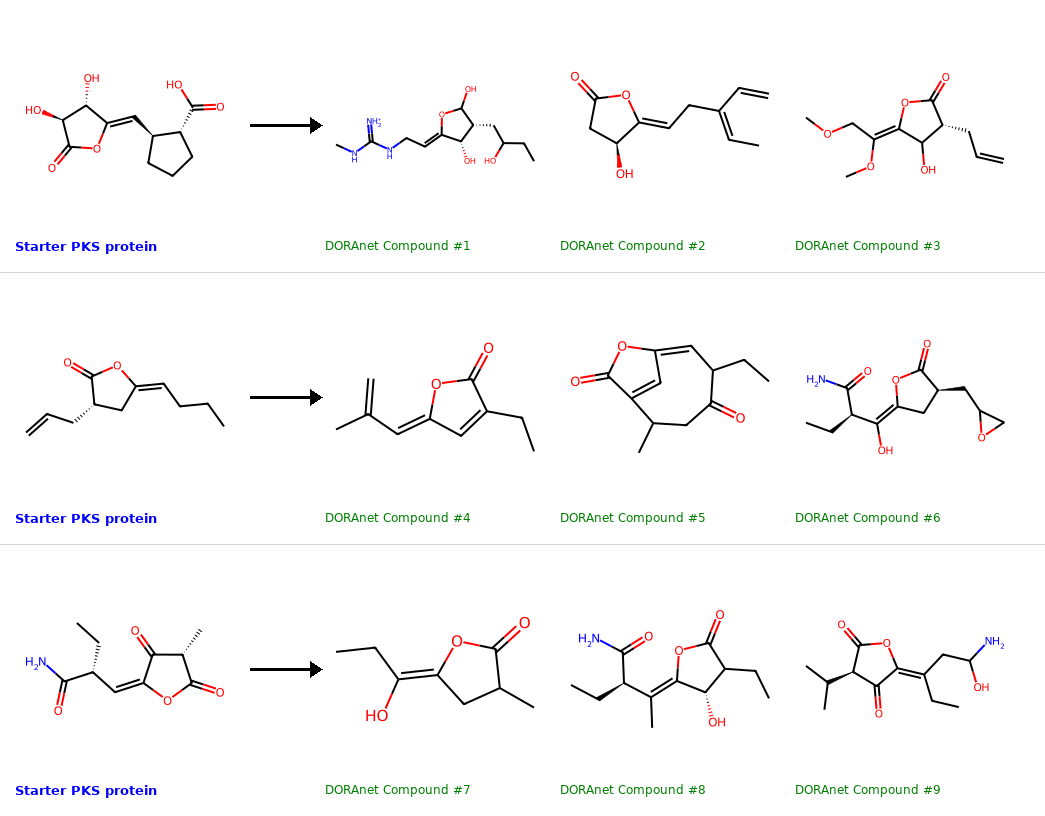

In [16]:
import itertools
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, Image as IPImage

sourceDF = reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers

MOL_SIZE       = (220, 220)
ROWS_PER_FRAME = 3
GENS_PER_ROW   = 3
MAX_FRAMES     = 100

# ── Step 1: Separate molecules ────────────────────────────────────────────────

starterSmiles   = sourceDF[sourceDF['Is_Starter'] == True]['SMILES'].tolist()
generatedSmiles = sourceDF[sourceDF['Is_Starter'] == False]['SMILES'].tolist()
starterSmilesSet = set(starterSmiles)

print(f"Source directory    : {sourceDF['SourceDirectory'].unique().tolist()}")
print(f"Starter molecules   : {len(starterSmiles)}")
print(f"Generated molecules : {len(generatedSmiles)}")

# ── Step 2: Build row data ────────────────────────────────────────────────────
# Column 1 cycles through starters then generated molecules
# Columns 2-4 show consecutive chunks of 3 generated molecules

col1Cycle = itertools.cycle(starterSmiles + generatedSmiles)

rowData = []
for genStart in range(0, len(generatedSmiles), GENS_PER_ROW):
    genChunk = generatedSmiles[genStart:genStart + GENS_PER_ROW]
    rowData.append((next(col1Cycle), genChunk, genStart))

framesGrouped = [
    rowData[i:i + ROWS_PER_FRAME]
    for i in range(0, len(rowData), ROWS_PER_FRAME)
]
print(f"Total frames available : {len(framesGrouped)}")

# ── Step 3: Sample frames before rendering ────────────────────────────────────

if len(framesGrouped) > MAX_FRAMES:
    sampleIndices = np.linspace(0, len(framesGrouped) - 1, MAX_FRAMES, dtype=int)
    framesSampled = [framesGrouped[i] for i in sampleIndices]
else:
    framesSampled = framesGrouped

print(f"Frames to render       : {len(framesSampled)}")

# ── Step 4: Pre-render only column 1 images needed for sampled frames ─────────

neededCol1Smiles = {row[0] for frame in framesSampled for row in frame}
col1ImageCache   = {}

def smiles_to_image(smiles, img_size=MOL_SIZE):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        img  = Image.new('RGB', img_size, 'white')
        draw = ImageDraw.Draw(img)
        draw.text((10, img_size[1] // 2), "Invalid SMILES", fill='red')
        return img
    return Draw.MolToImage(mol, size=img_size)

for smi in neededCol1Smiles:
    col1ImageCache[smi] = smiles_to_image(smi)

print(f"Column 1 images pre-rendered : {len(col1ImageCache)}")

# ── Step 5: Frame rendering ───────────────────────────────────────────────────

def create_frame(rows, col1ImageCache, mol_size=MOL_SIZE):
    """
    Create one GIF frame with ROWS_PER_FRAME rows.
    Each row layout: [col1 molecule] --> [gen1] [gen2] [gen3]

    rows           : list of (col1_smiles, [gen_smiles, ...], start_index)
    col1ImageCache : dict of {smiles: PIL.Image} — pre-rendered column 1 images
    """
    padding      = 15
    arrow_width  = 60
    label_height = 22
    row_height   = mol_size[1] + label_height + padding * 2
    frame_height = row_height * len(rows)

    col1_x        = padding
    arrow_x_start = col1_x + mol_size[0] + padding
    arrow_x_end   = arrow_x_start + arrow_width
    gen_x_start   = arrow_x_end + padding
    gen_col_width = mol_size[0] + padding
    frame_width   = gen_x_start + GENS_PER_ROW * gen_col_width + padding

    frame = Image.new('RGB', (frame_width, frame_height), 'white')
    draw  = ImageDraw.Draw(frame)

    try:
        font       = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 12)
        title_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 13)
    except (IOError, OSError):
        font = title_font = ImageFont.load_default()

    for row_idx, (col1_smi, gen_smiles_list, start_index) in enumerate(rows):
        mol_y   = row_idx * row_height + padding
        arrow_y = mol_y + mol_size[1] // 2

        # Column 1: pre-rendered image
        frame.paste(col1ImageCache[col1_smi], (col1_x, mol_y))
        col1_label = "Starter PKS protein" if col1_smi in starterSmilesSet else "PKS protein"
        draw.text(
            (col1_x, mol_y + mol_size[1] + 3),
            col1_label,
            fill='blue', font=title_font
        )

        # Arrow
        draw.line(
            [(arrow_x_start, arrow_y), (arrow_x_end, arrow_y)],
            fill='black', width=3
        )
        draw.polygon([
            (arrow_x_end,      arrow_y - 8),
            (arrow_x_end + 12, arrow_y),
            (arrow_x_end,      arrow_y + 8),
        ], fill='black')

        # Columns 2-4: generated molecules rendered on the fly
        for gen_idx, gen_smi in enumerate(gen_smiles_list[:GENS_PER_ROW]):
            gen_x = gen_x_start + gen_idx * gen_col_width
            frame.paste(smiles_to_image(gen_smi, mol_size), (gen_x, mol_y))
            draw.text(
                (gen_x, mol_y + mol_size[1] + 3),
                f"DORAnet Compound #{start_index + gen_idx + 1}",
                fill='green', font=font
            )

        # Row separator
        if row_idx < len(rows) - 1:
            sep_y = (row_idx + 1) * row_height
            draw.line([(0, sep_y), (frame_width, sep_y)], fill='lightgray', width=1)

    return frame

# ── Step 6: Render sampled frames ─────────────────────────────────────────────

allFrameImages = []
for frame_idx, frameRows in enumerate(framesSampled):
    allFrameImages.append(create_frame(frameRows, col1ImageCache))
    if (frame_idx + 1) % 25 == 0:
        print(f"Rendered frame {frame_idx + 1}/{len(framesSampled)}")

# ── Step 7: Save GIF ──────────────────────────────────────────────────────────

gifOutputPath = f"{fileNamePrefix}_highFeasibility.gif"
allFrameImages[0].save(
    gifOutputPath,
    save_all=True,
    append_images=allFrameImages[1:],
    duration=3000,
    loop=0
)
print(f"Saved GIF    : {gifOutputPath}")
print(f"Total frames : {len(allFrameImages)}")

display(IPImage(filename=gifOutputPath))

### Drug-Likeness Analysis of molecules present in `uniqueMolecules`

Drug-likeness is a qualitative assessment used in drug discovery to determine whether a molecule has physicochemical and structural properties consistent with orally active drugs. Molecules that satisfy drug-likeness criteria are more likely to exhibit favorable **absorption, distribution, metabolism, excretion, and toxicity (ADMET)** profiles.

In this analysis, each unique molecule is evaluated against **five widely used drug-likeness filters**:

### 1. Lipinski's Rule of Five (Ro5)
Proposed by **Christopher Lipinski (1997)**, this is the most well-known drug-likeness filter. It predicts poor absorption or permeation when **more than one** of the following conditions is violated:

- Molecular Weight ≤ 500 Da
- LogP ≤ 5
- Hydrogen Bond Donors (HBD) ≤ 5
- Hydrogen Bond Acceptors (HBA) ≤ 10

> **Reference:** Lipinski, C.A. et al. *Adv. Drug Deliv. Rev.* **23**, 3–25 (1997). [DOI:10.1016/S0169-409X(96)00423-1](https://doi.org/10.1016/S0169-409X(96)00423-1)

### 2. Veber's Rules
Proposed by **Veber et al. (2002)**, these rules focus on oral bioavailability based on molecular flexibility and polar surface area:

- Number of Rotatable Bonds ≤ 10
- Topological Polar Surface Area (TPSA) ≤ 140 Å²

> **Reference:** Veber, D.F. et al. *J. Med. Chem.* **45**, 2615–2623 (2002). [DOI:10.1021/jm020017n](https://doi.org/10.1021/jm020017n)

### 3. Ghose Filter
Proposed by **Ghose et al. (1999)**, this filter defines a drug-like chemical space using ranges for key properties:

- 160 ≤ Molecular Weight ≤ 480 Da
- −0.4 ≤ LogP ≤ 5.6
- 20 ≤ Number of Heavy Atoms ≤ 70
- 40 ≤ Molar Refractivity ≤ 130

> **Reference:** Ghose, A.K. et al. *J. Comb. Chem.* **1**, 55–68 (1999). [DOI:10.1021/cc9800071](https://doi.org/10.1021/cc9800071)

### 4. Egan Filter
Proposed by **Egan et al. (2000)**, this filter predicts passive intestinal absorption using a simple two-parameter model:

- LogP ≤ 5.88
- TPSA ≤ 131.6 Å²

> **Reference:** Egan, W.J. et al. *J. Med. Chem.* **43**, 3867–3877 (2000). [DOI:10.1021/jm000292e](https://doi.org/10.1021/jm000292e)

### 5. Muegge Filter
Proposed by **Muegge et al. (2001)**, this pharmacophore-based filter uses a broader set of criteria to identify drug-like molecules:

- 200 ≤ Molecular Weight ≤ 600 Da
- −2 ≤ LogP ≤ 5
- TPSA ≤ 150 Å²
- Number of Rings ≤ 7
- Hydrogen Bond Acceptors ≤ 10
- Hydrogen Bond Donors ≤ 5
- Number of Rotatable Bonds ≤ 15
- Number of Heavy Atoms ≥ 8

> **Reference:** Muegge, I. et al. *J. Med. Chem.* **44**, 1841–1846 (2001). [DOI:10.1021/jm015507e](https://doi.org/10.1021/jm015507e)

### Drug-Like Score

Each molecule receives a **DrugLikeScore** ranging from **0 to 5**, representing the number of filters it passes. A score of **5** indicates the molecule satisfies all five drug-likeness criteria, suggesting strong potential as an orally bioavailable drug candidate.

| DrugLikeScore | Interpretation |
|:---:|:---|
| 5 | Excellent drug-likeness — passes all filters |
| 4 | Strong drug-likeness — minor deviation in one filter |
| 3 | Moderate drug-likeness |
| 2 | Weak drug-likeness |
| 1 | Poor drug-likeness |
| 0 | Not drug-like by any standard filter |

### Molecular Properties Computed

| Property | Description | Used By |
|:---|:---|:---|
| Molecular Weight (MW) | Exact molecular weight in Daltons | Lipinski, Ghose, Muegge |
| LogP | Octanol-water partition coefficient (lipophilicity) | Lipinski, Ghose, Egan, Muegge |
| HBD | Number of hydrogen bond donors | Lipinski, Muegge |
| HBA | Number of hydrogen bond acceptors | Lipinski, Muegge |
| TPSA | Topological polar surface area (Å²) | Veber, Egan, Muegge |
| Rotatable Bonds | Number of rotatable bonds | Veber, Muegge |
| Heavy Atoms | Number of non-hydrogen atoms | Ghose, Muegge |
| Molar Refractivity | Measure of molecular polarizability | Ghose |
| Rings | Total number of rings | Muegge |
| Aromatic Rings | Number of aromatic rings | Structural characterization |

> **Note:** These filters are designed primarily for **orally active small molecules**. Natural products and biologics may legitimately violate some criteria while still being therapeutically relevant. The DrugLikeScore should be interpreted as a guide, not an absolute cutoff.

In [ ]:
from rdkit.Chem import Descriptors, rdMolDescriptors, Lipinski


# Drug-likeness filter functions
def computeDrugLikeProperties(smiles):
    """Compute drug-likeness properties from SMILES."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return pd.Series({
            'MolWeight': None,
            'LogP': None,
            'NumHBD': None,
            'NumHBA': None,
            'TPSA': None,
            'NumRotatableBonds': None,
            'NumRings': None,
            'NumAromaticRings': None,
            'NumHeavyAtoms': None,
            'MolarRefractivity': None,
            'PassesLipinski': False,
            'LipinskiViolations': None,
            'PassesVeber': False,
            'PassesGhose': False,
            'PassesEgan': False,
            'PassesMuegge': False,
            'DrugLikeScore': 0,
            'IsValidMol': False
        })

    molWeight = Descriptors.ExactMolWt(mol)
    logP = Descriptors.MolLogP(mol)
    numHBD = rdMolDescriptors.CalcNumHBD(mol)
    numHBA = rdMolDescriptors.CalcNumHBA(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    numRotatableBonds = rdMolDescriptors.CalcNumRotatableBonds(mol)
    numRings = rdMolDescriptors.CalcNumRings(mol)
    numAromaticRings = rdMolDescriptors.CalcNumAromaticRings(mol)
    numHeavyAtoms = mol.GetNumHeavyAtoms()
    molarRefractivity = Descriptors.MolMR(mol)

    lipinskiViolations = 0
    if molWeight > 500:
        lipinskiViolations += 1
    if logP > 5:
        lipinskiViolations += 1
    if numHBD > 5:
        lipinskiViolations += 1
    if numHBA > 10:
        lipinskiViolations += 1
    passesLipinski = lipinskiViolations <= 1

    passesVeber = (numRotatableBonds <= 10) and (tpsa <= 140)

    passesGhose = (
        (160 <= molWeight <= 480) and
        (-0.4 <= logP <= 5.6) and
        (20 <= numHeavyAtoms <= 70) and
        (40 <= molarRefractivity <= 130)
    )

    passesEgan = (logP <= 5.88) and (tpsa <= 131.6)

    passesMuegge = (
        (200 <= molWeight <= 600) and
        (-2 <= logP <= 5) and
        (tpsa <= 150) and
        (numRings <= 7) and
        (numHBA <= 10) and
        (numHBD <= 5) and
        (numRotatableBonds <= 15) and
        (numHeavyAtoms >= 8)
    )

    drugLikeScore = sum([
        passesLipinski,
        passesVeber,
        passesGhose,
        passesEgan,
        passesMuegge
    ])

    return pd.Series({
        'MolWeight': round(molWeight, 4),
        'LogP': round(logP, 4),
        'NumHBD': numHBD,
        'NumHBA': numHBA,
        'TPSA': round(tpsa, 2),
        'NumRotatableBonds': numRotatableBonds,
        'NumRings': numRings,
        'NumAromaticRings': numAromaticRings,
        'NumHeavyAtoms': numHeavyAtoms,
        'MolarRefractivity': round(molarRefractivity, 4),
        'PassesLipinski': passesLipinski,
        'LipinskiViolations': lipinskiViolations,
        'PassesVeber': passesVeber,
        'PassesGhose': passesGhose,
        'PassesEgan': passesEgan,
        'PassesMuegge': passesMuegge,
        'DrugLikeScore': drugLikeScore,
        'IsValidMol': True
    })


# Compute drug-likeness for all molecules
print(f"Computing drug-likeness properties for {len(uniqueMolecules)} molecules...")

drugLikeProperties = uniqueMolecules['SMILES'].apply(computeDrugLikeProperties)

uniqueMoleculesDrug = pd.concat(
    [uniqueMolecules.reset_index(drop=True), drugLikeProperties],
    axis=1
)

invalidMolCount = len(uniqueMoleculesDrug[~uniqueMoleculesDrug['IsValidMol']])
print(f"Invalid molecules: {invalidMolCount}")
print(f"Final DataFrame shape: {uniqueMoleculesDrug.shape}")

# Summary
validMols = uniqueMoleculesDrug[uniqueMoleculesDrug['IsValidMol']]
totalValid = len(validMols)

lipinskiCount = validMols['PassesLipinski'].sum()
veberCount = validMols['PassesVeber'].sum()
ghoseCount = validMols['PassesGhose'].sum()
eganCount = validMols['PassesEgan'].sum()
mueggeCount = validMols['PassesMuegge'].sum()
allFiveCount = len(validMols[validMols['DrugLikeScore'] == 5])
nonePassedCount = len(validMols[validMols['DrugLikeScore'] == 0])

print("\nDrug likeliness summary:")
print(f"Total valid molecules: {totalValid}")
print(f"  Passes Lipinski (Ro5):  {lipinskiCount} ({lipinskiCount/totalValid*100:.2f}%)")
print(f"  Passes Veber:           {veberCount} ({veberCount/totalValid*100:.2f}%)")
print(f"  Passes Ghose:           {ghoseCount} ({ghoseCount/totalValid*100:.2f}%)")
print(f"  Passes Egan:            {eganCount} ({eganCount/totalValid*100:.2f}%)")
print(f"  Passes Muegge:          {mueggeCount} ({mueggeCount/totalValid*100:.2f}%)")
print(f"\n  Passes ALL 5 filters:   {allFiveCount} ({allFiveCount/totalValid*100:.2f}%)")
print(f"  Passes NONE:            {nonePassedCount} ({nonePassedCount/totalValid*100:.2f}%)")

# DrugLikeScore distribution
print(f"\nDrugLikeScore Distribution:")
for score in range(6):
    count = len(validMols[validMols['DrugLikeScore'] == score])
    print(f"  Score {score}/5: {count} ({count/totalValid*100:.2f}%)")

# Breakdown: starters vs generated
startersDrug = validMols[validMols['Is_Starter'] == True]
generatedDrug = validMols[validMols['Is_Starter'] == False]

starterAllFive = len(startersDrug[startersDrug['DrugLikeScore'] == 5])
generatedAllFive = len(generatedDrug[generatedDrug['DrugLikeScore'] == 5])

starterPercent = (starterAllFive / len(startersDrug) * 100) if len(startersDrug) > 0 else 0
generatedPercent = (generatedAllFive / len(generatedDrug) * 100) if len(generatedDrug) > 0 else 0

print(f"\nAmong starters:  {starterAllFive}/{len(startersDrug)} pass all 5 ({starterPercent:.2f}%)")
print(f"Among generated: {generatedAllFive}/{len(generatedDrug)} pass all 5 ({generatedPercent:.2f}%)")

uniqueMoleculesDrug

### Check matches for Natural Product from public data bases via `SMILES`
 - NPAtlas: https://www.npatlas.org/download
 - COCONUT: https://coconut.naturalproducts.net/download

## Natural Product Matching via `InChIKey`

# How many pathways has been generated

In [ ]:
import PyPDF2

# Automatically find all starter directories (exclude files)
allStarterDirPaths = sorted([
    p for p in glob.glob(os.path.join(doranetOutputDir, "starter_*"))
    if os.path.isdir(p)
])

totalStarterDirs = len(allStarterDirPaths)
print(f"Found {totalStarterDirs} starter molecules")

# Count pathways from PDF files in each directory
pathwayCountsPerStarter = []

for starterDirPath in allStarterDirPaths:
    dirName = os.path.basename(starterDirPath)
    starterNum = int(dirName.replace('starter_', ''))

    expectedPdfPath = os.path.join(starterDirPath, f"{dirName}_pathways_visualized.pdf")

    if not os.path.exists(expectedPdfPath):
        fallbackPdfPaths = glob.glob(os.path.join(starterDirPath, "*_pathways_visualized.pdf"))
        expectedPdfPath = fallbackPdfPaths[0] if fallbackPdfPaths else None

    numPathways = 0
    if expectedPdfPath and os.path.exists(expectedPdfPath):
        try:
            with open(expectedPdfPath, 'rb') as pdfFile:
                pdfReader = PyPDF2.PdfReader(pdfFile)
                numPathways = len(pdfReader.pages)
        except Exception as e:
            print(f"Error reading PDF for {dirName}: {e}")

    pathwayCountsPerStarter.append({
        'StarterDirectory': dirName,
        'StarterNum': starterNum,
        'NumPathways': numPathways
    })

allPathwaysRaw = pd.DataFrame(pathwayCountsPerStarter).sort_values('StarterNum').reset_index(drop=True)

# Keep only starters with pathways
allPathways = allPathwaysRaw[allPathwaysRaw['NumPathways'] > 0].copy().reset_index(drop=True)

totalPathways = allPathways['NumPathways'].sum()
startersWithPathways = len(allPathways)
startersWithoutPathways = totalStarterDirs - startersWithPathways
withPercent = (startersWithPathways / totalStarterDirs) * 100
withoutPercent = (startersWithoutPathways / totalStarterDirs) * 100

print(f"Total pathways found: {totalPathways}")
print(f"Starters with pathways: {startersWithPathways} ({withPercent:.2f}%), "
      f"without: {startersWithoutPathways} ({withoutPercent:.2f}%)")

allPathways = allPathways.drop(columns=['StarterNum'])
allPathways

### Extract pathway infromation to products and reactants 

In [ ]:
import pandas as pd
import numpy as np
import os
import re
import glob


# Helper Functions
def readTextFile(txtPath: str) -> str:
    """Read a text file and return its content."""
    with open(txtPath, "r", encoding="utf-8") as f:
        return f.read()


def splitReactionSmiles(rxnSmiles: str):
    """Split a reaction SMILES into reactants and products."""
    left, right = rxnSmiles.split(">>")
    reactants = [s for s in left.split(".") if s]
    products = [s for s in right.split(".") if s]
    return reactants, products

def getUniqueCanonicalSmiles(column: pd.Series) -> set:
    """Extract unique canonical SMILES from a pipe-separated column."""
    allSmiles = set()
    for entry in column.dropna():
        # Split by ' | ' (step separator) then by '.' (molecule separator)
        for step in entry.split(' | '):
            for smi in step.split('.'):
                smi = smi.strip()
                if smi:
                    mol = Chem.MolFromSmiles(smi)
                    if mol is not None:
                        canonical = Chem.MolToSmiles(mol)
                        allSmiles.add(canonical)
    return allSmiles

# Parser
def parseRankedPathwayTxtForDF(txt: str) -> list:
    """Parse ranked pathway text and extract structured data for each pathway."""
    blocks = re.split(r"\branking\s+", txt.strip())
    pathwayRecords = []

    for block in blocks:
        if not block.strip():
            continue

        # Extract ranking number
        rankMatch = re.match(r"(\d+)\s*", block)
        if not rankMatch:
            continue
        rank = int(rankMatch.group(1))

        lines = block.splitlines()

        # Extract scores
        def findFloat(pattern, default=float("nan")):
            m = re.search(pattern, block)
            return float(m.group(1)) if m else default

        finalScore = findFloat(r"final\s+score\s+([0-9.]+)")
        atomicEconomy = findFloat(r"atomic\s+economy\s+([0-9.]+)")

        # Extract pathway by-product
        pathwayByProduct = findFloat(r"pathway\s+by-product\s+([0-9.]+)")

        # Extract reaction SMILES (lines containing '>>' but not headers)
        reactionLines = []
        for line in lines:
            line = line.strip()
            if ">>" in line and not line.lower().startswith("reaction smiles"):
                reactionLines.append(line)

        # Extract rule names
        ruleNames = []
        for line in lines:
            line = line.strip()
            if line.startswith("rule"):
                ruleNames.append(line)

        # Extract thermodynamic data after rule lines
        # In your file format, thermo entries follow rule lines (one per step)
        # They can be "No_Thermo" or actual numeric values
        thermoValues = []
        ruleIndices = [i for i, ln in enumerate(lines) if lines[i].strip().startswith("rule")]

        if ruleIndices:
            lastRuleIdx = ruleIndices[-1]
            for line in lines[lastRuleIdx + 1:]:
                line = line.strip()
                if not line:
                    continue
                if line == "No_Thermo":
                    thermoValues.append(float("nan"))
                else:
                    try:
                        thermoValues.append(float(line))
                    except ValueError:
                        continue

        # Extract stoichiometry
        stoichiometry = ""
        for line in lines:
            if "stoichiometry" in line.lower():
                stoichiometry = line.strip()
                break

        # Extract reactants and products per step
        perStepReactants = []
        perStepProducts = []
        for rxnSmiles in reactionLines:
            reactants, products = splitReactionSmiles(rxnSmiles)
            perStepReactants.append('.'.join(reactants))
            perStepProducts.append('.'.join(products))

        # Format thermo per step
        thermoPerStep = []
        for i in range(len(reactionLines)):
            if i < len(thermoValues):
                val = thermoValues[i]
                thermoPerStep.append("No_Thermo" if pd.isna(val) else f"{val:.4f}")
            else:
                thermoPerStep.append("N/A")

        # Check if any thermo data is available
        hasThermo = any(not pd.isna(v) for v in thermoValues) if thermoValues else False

        # Compute average Gibbs free energy (only from available values)
        validThermoValues = [v for v in thermoValues if not pd.isna(v)]
        avgGibbsFreeEnergy = (
            sum(validThermoValues) / len(validThermoValues)
            if validThermoValues else float("nan")
        )

        pathwayRecords.append({
            'PathwayNumber': rank,
            'FinalScore': finalScore,
            'AtomicEconomy': atomicEconomy,
            'PathwayByProduct': pathwayByProduct,
            'NumSteps': len(reactionLines),
            'Reactant': ' | '.join(perStepReactants),
            'Product': ' | '.join(perStepProducts),
            'ReactionSMILES': ' | '.join(reactionLines),
            'RuleNames': ' | '.join(ruleNames),
            'Stoichiometry': stoichiometry,
            'ThermoPerStep': ' | '.join(thermoPerStep),
            'HasThermo': hasThermo,
            'AvgGibbsFreeEnergy': avgGibbsFreeEnergy
        })

    return pathwayRecords



# DataFrame Builder
def buildPathwaysDF(doranetOutputDir: str) -> pd.DataFrame:
    """
    Automatically find all *_ranked_pathways.txt files inside
    starter_* directories under doranetOutputDir, parse them,
    and build a consolidated DataFrame.
    """
    allRecords = []

    # Automatically find all ranked pathway text files
    txtFilePattern = os.path.join(doranetOutputDir, "starter_*", "*_ranked_pathways.txt")
    txtFiles = sorted(glob.glob(txtFilePattern))

    totalStarterDirs = len(sorted(glob.glob(os.path.join(doranetOutputDir, "starter_*"))))

    print(f"Total starter directories: {totalStarterDirs}")
    print(f"Found {len(txtFiles)} ranked pathway text files")

    parsedCount = 0
    errorCount = 0
    emptyCount = 0

    for txtPath in txtFiles:
        # Extract starter directory name from file path
        dirName = os.path.basename(os.path.dirname(txtPath))

        try:
            txt = readTextFile(txtPath)

            # Skip empty files
            if not txt.strip():
                emptyCount += 1
                continue

            pathwayRecords = parseRankedPathwayTxtForDF(txt)

            if pathwayRecords:
                for record in pathwayRecords:
                    record['StarterDirectory'] = dirName
                    allRecords.append(record)
                parsedCount += 1
            else:
                emptyCount += 1

        except Exception as e:
            print(f"  Error parsing {dirName}: {e}")
            errorCount += 1

    print(f"\nSuccessfully parsed: {parsedCount} starters")
    print(f"Empty or no pathways: {emptyCount} starters")
    if errorCount > 0:
        print(f"Errors: {errorCount} starters")
    print(f"Starters without pathway file: {totalStarterDirs - len(txtFiles)}")

    # Create DataFrame
    pathwaysDF = pd.DataFrame(allRecords)

    if not pathwaysDF.empty:
        # Count pathways per starter
        numPathwaysPerStarter = (
            pathwaysDF.groupby('StarterDirectory')['PathwayNumber']
            .count()
            .reset_index()
            .rename(columns={'PathwayNumber': 'NumPathways'})
        )
        pathwaysDF = pathwaysDF.merge(numPathwaysPerStarter, on='StarterDirectory', how='left')

        # Reorder columns
        columnOrder = [
            'StarterDirectory', 'NumPathways', 'PathwayNumber',
            'FinalScore', 'AtomicEconomy', 'PathwayByProduct',
            'NumSteps', 'Reactant', 'Product',
            'ReactionSMILES', 'RuleNames', 'Stoichiometry',
            'ThermoPerStep', 'HasThermo', 'AvgGibbsFreeEnergy'
        ]
        existingColumns = [c for c in columnOrder if c in pathwaysDF.columns]
        pathwaysDF = pathwaysDF[existingColumns]

    return pathwaysDF


# Get pathways
pathwaysDF = buildPathwaysDF(doranetOutputDir)

print(f"\nTotal pathways: {len(pathwaysDF)}")

if not pathwaysDF.empty:
    print(f"Total starters with pathways: {pathwaysDF['StarterDirectory'].nunique()}")
    #print(f"Columns: {pathwaysDF.columns.tolist()}")

    # Thermo summary
    thermoCount = pathwaysDF['HasThermo'].sum()
    noThermoCount = (~pathwaysDF['HasThermo']).sum()
    print(f"\nPathways with thermodynamic data: {thermoCount}")
    print(f"Pathways without thermodynamic data: {noThermoCount}")

    if thermoCount > 0:
        print("\nSample pathways with thermodynamic data:")
        print(pathwaysDF[pathwaysDF['HasThermo']][
            ['StarterDirectory', 'PathwayNumber', 'ThermoPerStep', 'AvgGibbsFreeEnergy']
        ].head(10).to_string(index=False))

    
else:
    print("No pathways found.")
    print(f"Check that txt files exist at: {doranetOutputDir}/starter_*/{{name}}_ranked_pathways.txt")


# Count unique canonical products and reactants
uniqueReactants = getUniqueCanonicalSmiles(pathwaysDF['Reactant'])
uniqueProducts = getUniqueCanonicalSmiles(pathwaysDF['Product'])

print(f"\nUnique canonical reactants: {len(uniqueReactants)}")
print(f"Unique canonical products: {len(uniqueProducts)}")

# Molecules that appear as both reactant and product (intermediates)
intermediates = uniqueReactants & uniqueProducts
print(f"Shared (intermediates): {len(intermediates)}")

# Molecules unique to reactants or products
onlyReactants = uniqueReactants - uniqueProducts
onlyProducts = uniqueProducts - uniqueReactants
print(f"Only in reactants (starting materials): {len(onlyReactants)}")
print(f"Only in products (final products + byproducts): {len(onlyProducts)}")

pathwaysDF = pathwaysDF.drop(columns=['FinalScore', 'PathwayByProduct', 'NumSteps', 'RuleNames', 'Stoichiometry', 'ThermoPerStep', 'HasThermo', 'AvgGibbsFreeEnergy'])
pathwaysDF.to_csv(os.path.join(doranetOutputDir, f"{fileNamePrefix}_pathways.csv"), index=False, encoding="utf-8")
pathwaysDF.head()

### Visualize pathways

### Discover All Starter Directories

In [ ]:
doranetOutputDir_NP = "doranet_output_NP"

helpersToExclude = {
    'O', 'O=O', '[H][H]', 'O=C=O', 'C=O', '[C-]#[O+]', 'Br', '[Br][Br]',
    'CO', 'C=C', 'O=S(O)O', 'N', 'O=S(=O)(O)O', 'O=NO', 'N#N',
    'O=[N+]([O-])O', 'NO', 'C#N', 'S', 'O=S=O', 'N#CO', '[H+]', 'OO',
    'Cl', 'I', 'O=C(O)O', 'O=P(O)(O)O', 'O=P(O)(O)OP(=O)(O)O', 'C',
    'CC', 'CC=O', 'CC(=O)O', 'CCC(=O)O'
}

print(f"Output directory: {doranetOutputDir_NP}")
print(f"Number of helpers to exclude: {len(helpersToExclude)}")

In [ ]:
# Automatically find all starter directories
allStarterDirPaths_NP = sorted(glob.glob(os.path.join(doranetOutputDir_NP, "starter_*_NP")))

print(f"Found {len(allStarterDirPaths_NP)} starter directories")

# Find the molecules CSV file inside each directory
discoveredCsvFiles = []
directoriesWithMissingCsv = []

for starterDirPath in allStarterDirPaths_NP:
    dirName = os.path.basename(starterDirPath)

    # Expected CSV file name matches directory name
    expectedCsvPath = os.path.join(starterDirPath, f"{dirName}_molecules.csv")

    if os.path.exists(expectedCsvPath):
        discoveredCsvFiles.append({
            'dirName': dirName,
            'dirPath': starterDirPath,
            'csvPath': expectedCsvPath,
            'starterNum': int(dirName.replace('starter_', '').replace('_NP', ''))
        })
    else:
        # Try to find any molecules CSV in the directory as fallback
        fallbackCsvPaths = glob.glob(os.path.join(starterDirPath, "*_molecules.csv"))
        if fallbackCsvPaths:
            discoveredCsvFiles.append({
                'dirName': dirName,
                'dirPath': starterDirPath,
                'csvPath': fallbackCsvPaths[0],
                'starterNum': int(dirName.replace('starter_', '').replace('_NP', ''))
            })
        else:
            directoriesWithMissingCsv.append(dirName)

# Sort by starter number
discoveredCsvFiles.sort(key=lambda x: x['starterNum'])

print(f"Found {len(discoveredCsvFiles)} CSV files containing DORAnet generated molecules")
if directoriesWithMissingCsv:
    print(f"Missing CSV in {len(directoriesWithMissingCsv)} directories: "
          f"{directoriesWithMissingCsv[:10]}...")

### Read All CSV Files into a DataFrame

In [ ]:
# Read all CSV files and combine into one DataFrame
perStarterDataFrames = []
csvReadErrors = []

for fileInfo in discoveredCsvFiles:
    try:
        singleStarterMolecules = pd.read_csv(fileInfo['csvPath'])

        # Add source starter information
        singleStarterMolecules['SourceStarterNum'] = fileInfo['starterNum']
        singleStarterMolecules['SourceDirectory'] = fileInfo['dirName']

        perStarterDataFrames.append(singleStarterMolecules)

    except Exception as e:
        csvReadErrors.append({
            'dirName': fileInfo['dirName'],
            'csvPath': fileInfo['csvPath'],
            'error': str(e)
        })

# Concatenate all DataFrames
if perStarterDataFrames:
    allMoleculesWithDuplicates_wNP = pd.concat(perStarterDataFrames, ignore_index=True)
    print(f"Total rows read (with duplicates and helpers): {len(allMoleculesWithDuplicates_wNP)}")
    print(f"Columns: {list(allMoleculesWithDuplicates_wNP.columns)}")
    print(f"Unique SMILES (before cleaning): {allMoleculesWithDuplicates_wNP['SMILES'].nunique()}")
else:
    print("ERROR: No CSV files could be read!")

if csvReadErrors:
    print(f"\nFailed to read {len(csvReadErrors)} files:")
    for err in csvReadErrors[:5]:
        print(f"  {err['dirName']}: {err['error']}")

allMoleculesWithDuplicates_wNP

### Remove HELPERS and Deduplicate

In [ ]:
# Step 1: Remove helpers
reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers = allMoleculesWithDuplicates_wNP[
    ~allMoleculesWithDuplicates_wNP['SMILES'].isin(helpersToExclude)
].copy()

helpersRemovedCount = len(allMoleculesWithDuplicates_wNP) - len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers)
helpersKeptPercent = (len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers) / len(allMoleculesWithDuplicates_wNP)) * 100
print(f"Step 1 - Removed {helpersRemovedCount} helper molecules")
print(f"Remaining molecules: {len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers)} ({helpersKeptPercent:.2f}%)")

# Step 2: Aggregate source starters per unique SMILES
sourceStarterMapping = (
    reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers
    .groupby('SMILES')['SourceStarterNum']
    .apply(lambda x: sorted(set(x)))
    .reset_index()
)
sourceStarterMapping.columns = ['SMILES', 'SourceStarterList']
sourceStarterMapping['NumSourceStarters'] = sourceStarterMapping['SourceStarterList'].apply(len)
sourceStarterMapping['SourceStarters'] = sourceStarterMapping['SourceStarterList'].apply(
    lambda x: ';'.join(map(str, x))
)

# Also aggregate source directories per unique SMILES
sourceDirectoryMapping = (
    reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers
    .groupby('SMILES')['SourceDirectory']
    .apply(lambda x: ';'.join(sorted(set(x))))
    .reset_index()
)
sourceDirectoryMapping.columns = ['SMILES', 'SourceDirectories']

# Step 3: Deduplicate - keep first occurrence of each SMILES
uniqueMolecules_wNP = reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers.drop_duplicates(
    subset='SMILES', keep='first'
).copy()

# Keep only desired columns
uniqueMolecules_wNP = uniqueMolecules_wNP[['SMILES', 'Is_Starter']].copy()

# Step 4: Merge aggregated source starter and directory information
uniqueMolecules_wNP = uniqueMolecules_wNP.merge(
    sourceStarterMapping[['SMILES', 'NumSourceStarters', 'SourceStarters']],
    on='SMILES',
    how='left'
)
uniqueMolecules_wNP = uniqueMolecules_wNP.merge(
    sourceDirectoryMapping,
    on='SMILES',
    how='left'
)

duplicatesRemovedCount = len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers) - len(uniqueMolecules_wNP)
dedupeKeptPercent = (len(uniqueMolecules_wNP) / len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers)) * 100
overallKeptPercent = (len(uniqueMolecules_wNP) / len(allMoleculesWithDuplicates_wNP)) * 100

print(f"Step 2 - Removed {duplicatesRemovedCount} duplicate molecular SMILES ({dedupeKeptPercent:.2f}%)")
print(f"Final unique molecules: {len(uniqueMolecules_wNP)} ({overallKeptPercent:.2f}% of original)")

uniqueMolecules_wNP = uniqueMolecules_wNP.drop(columns=['NumSourceStarters', 'SourceStarters'])
uniqueMolecules_wNP

### How many pathways has been generated 

In [ ]:
import PyPDF2

# Count pathways from PDF files in each directory
pathwayCountsPerStarter = []

for starterDirPath in allStarterDirPaths_NP:
    dirName = os.path.basename(starterDirPath)
    starterNum = int(dirName.replace('starter_', '').replace('_NP', ''))

    expectedPdfPath = os.path.join(starterDirPath, f"{dirName}_pathways_visualized.pdf")

    if not os.path.exists(expectedPdfPath):
        fallbackPdfPaths = glob.glob(os.path.join(starterDirPath, "*_pathways_visualized.pdf"))
        expectedPdfPath = fallbackPdfPaths[0] if fallbackPdfPaths else None

    numPathways = 0
    if expectedPdfPath and os.path.exists(expectedPdfPath):
        try:
            with open(expectedPdfPath, 'rb') as pdfFile:
                pdfReader = PyPDF2.PdfReader(pdfFile)
                numPathways = len(pdfReader.pages)
        except Exception as e:
            print(f"Error reading PDF for {dirName}: {e}")

    pathwayCountsPerStarter.append({
        'StarterDirectory': dirName,
        'StarterNum': starterNum,
        'NumPathways': numPathways
    })

allPathways_wNPRaw = pd.DataFrame(pathwayCountsPerStarter).sort_values('StarterNum').reset_index(drop=True)

# Keep only starters with pathways
allPathways_wNP = allPathways_wNPRaw[allPathways_wNPRaw['NumPathways'] > 0].copy().reset_index(drop=True)

totalStarterDirs_NP = len(allStarterDirPaths_NP)
totalPathways = allPathways_wNP['NumPathways'].sum()
startersWithPathways = len(allPathways_wNP)
startersWithoutPathways = totalStarterDirs_NP - startersWithPathways
withPercent = (startersWithPathways / totalStarterDirs_NP) * 100
withoutPercent = (startersWithoutPathways / totalStarterDirs_NP) * 100

print(f"Total pathways found: {totalPathways}")
print(f"Starters with pathways: {startersWithPathways} ({withPercent:.2f}%), "
      f"without: {startersWithoutPathways} ({withoutPercent:.2f}%)")

allPathways_wNP = allPathways_wNP.drop(columns=['StarterNum'])
allPathways_wNP